### Advection Problem — Temperature

- Simulates temperature advection over a 2‑D $x$–$z$ column, marching in $x$ and solving an implicit vertical problem at each $\Delta x$.
- Uses a tridiagonal Thomas solve with central differences in $z$ at every $x$‑station for robustness.

- Governing balance:
  $$
  U(z)\,\frac{\partial T}{\partial x} \;=\; \frac{\partial}{\partial z}\!\Big(K(z)\,\frac{\partial T}{\partial z}\Big).
  $$
- Closures employed:
  - Neutral mean wind (log law): $U(z) = \dfrac{u_*}{k}\,\ln\!\big(z/z_0\big)$ with $k=0.4$.
  - Eddy diffusivity (first‑order closure): $K(z) = k\,u_*\,z$.
- Implicit marched form solved per step $\Delta x$:
  $$
  \frac{T(x+\Delta x,z)-T(x,z)}{\Delta x}
  \;=\;
  \frac{K(z)}{U(z)}\,\frac{\partial^2 T}{\partial z^2}
  \;+\;
  \frac{\partial_z K(z)}{U(z)}\,\frac{\partial T}{\partial z}.
  $$
  In code, arrays $A=K(z)$, $B=1/U(z)$, and $C=\partial_z K$ generate the tridiagonal coefficients.

Boundary and upstream conditions
- Vertical boundaries: $T(z=0)=T_s$, $T(z=H)=T_a$ (enforced by replacing the first/last rows of the system).
- Upstream column (neutral surface layer):
  $$
  w'T' \;=\; -\,\frac{(T_a - T_s)\,k\,u_*}{\ln(z_{\max}/z_0)}, 
  \qquad
  T_{\mathrm{up}}(z) \;=\; T_s \;-\; \frac{w'T'}{k\,u_*}\,\ln\!\Big(\frac{z}{z_0}\Big).
  $$
- Diagnostic flux reported:
  $$
  w'T'(z) \;=\; -\,K(z)\,\frac{\partial T}{\partial z}.
  $$



In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sys
import math
import numpy as np
sys.path.append("../../src")
for mod in ["sutton_functions"]:
    if mod in sys.modules:
            del sys.modules[mod]
            
from sutton_archive import *

In [2]:
temperature_C = 20 # Temperature in Celsius
temperature_K = temperature_C + 273.15  # Convert to Kelvin

es = saturation_vapor_pressure(temperature_K)
rho = vapor_concentration(es, temperature_K)

print(f"Saturation vapor pressure at {temperature_C}°C is {es:.2f} Pa")
print(f"Water vapor concentration at {temperature_C}°C is {rho:.2f} g/m³")


Saturation vapor pressure at 20°C is 2366.09 Pa
Water vapor concentration at 20°C is 17.49 g/m³


### Boundary conditions

In [3]:
# Water vapor script
k = 0.4  # von Karman constant
g = 9.8 

# Flow conditions
ustar = 0.2      # Friction velocity (m/s)
zom = 0.1/100    # Momentum roughness length (m)
zoh =  zom*7.4*np.exp(-2.4*(ustar*zom/1.5e-5)**0.25)
# R = ustar*zom/1.5e-5

# Domain specification
Lx = 2000
Hmax = 50

Lx=2000 
Hmax=50

xmin = 0
xmax = Lx
zmin = zom
zmax = Hmax

# Generate grid
nx = 1000
nz = 200
dx = (xmax - xmin) / nx
dz = (zmax - zmin) / nz

z = np.arange(zmin, zmax, dz)

zc = z.copy()
zc[0] = dz / np.log(z[1]/z[0])
for i in range(1, nz-1):
    zc[i] = dz*2/ np.log(z[i+1]/z[i-1])
zc[-1] = dz / np.log(z[-1]/z[-2])

x = np.arange(xmin, xmax + dx, dx)

# Generate the mean velocity from log-law
U = (ustar / k) * np.log(z / zom)

# Specify upwind temperature (as background), used to specify
# downwind surfce humidity
Ta_u = 25
Ts_u = 30
wT = - (Ta_u - Ts_u)*k*ustar/np.log(zmax/zom)
Tup = Ts_u - wT/(k*ustar)*np.log(z/zom)
Ts_d = 20
Ta_d = Ta_u

es = saturation_vapor_pressure(Ts_u + 273.15)
rho = vapor_concentration(es, Ts_u + 273.15)

# Water vapor boundary conditions (gm/m3)
Qs = rho      # Surface wv concentration
Qa = 25       # Upwind background atmospheric wv concentration
Qs_u = Qa
print("Water vapor boundary conditions = {0:.2f} (gm/m3) ".format( Qs))

Water vapor boundary conditions = 31.12 (gm/m3) 


## Solve water vapor

In [4]:
# Specify upwind wv concentration (as background)
Qup = np.ones(nz) * Qa

# Setup coefficients for implicit scheme
A = k * z * ustar
B = 1.0 / (U+ 1e-10)
C = our_central_difference(A, dz)

# Upwind wv concentrations and fluxes
Q1 = Qup
Q = np.zeros((nx + 1, nz))
Q[0, :] = Q1
FluxQ = np.zeros((nx + 1, nz))

dQdz = our_central_difference(Q1, dz)

Fq = np.zeros_like(Q1)
Fq[1:] = - 0.5 * (A[1:] + A[:-1]) * (0*dQdz[:-1] + dQdz[1:]) * 0.5

Fq[1] = Fq[2]
Fq[0] = Fq[1]


FluxQ[0, :] =  zc/z*Fq

# Begin downwind calculations by marching along x
for i in range(nx):
    integrate_H2O_implicit
    Q2, Fq = integrate_H2O_implicit(nx, nz, dx, dz, A, B, C, Q1, Qs, Qa)
    Q[i+1, :] = Q2
    FluxQ[i+1, :] = Fq
    Q1 = Q2

FluxQ[FluxQ < 1e-10] = 0    


### Temperature

In [5]:
# Setup coefficients for implicit scheme
A = k * z * ustar
B = 1.0 / (U + 1e-10)
C = our_central_difference(A, dz)

# Upwind wv concentrations and fluxes
T1 = Tup
T = np.zeros((nx + 1, nz))
T[0, :] = T1
FluxT = np.zeros((nx + 1, nz))

dTdz = our_central_difference(T1, dz)
# FT = - A * dTdz

FT = np.zeros_like(T1)

FT[1:] = - 0.5 * (A[1:] + A[:-1]) * (0*dTdz[:-1] + dTdz[1:]) * 0.5
FT[1] = FT[2]
FT[0] = FT[1]
FluxT[0, :]   = FT # zc/z

# Begin downwind calculations by marching along x
for i in range(nx):
    T2, FT = integrate_T_implicit(nx, nz, dx, dz, A, B, C, T1, Ts_d, Ta_d)
    T[i + 1, :] = T2
    FluxT[i + 1, :] = FT
    T1 = T2

(0.0, 0.1)

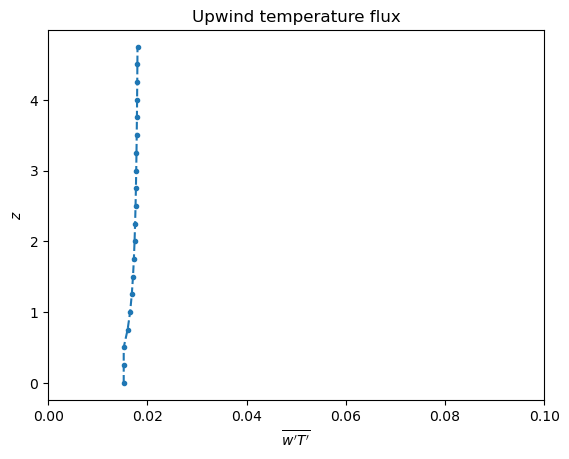

In [6]:
plt.plot(FluxT[0, :20], z[:20], '.--')
plt.xlabel("$\overline{w'T'}$")
plt.ylabel("$z$")
plt.title("Upwind temperature flux")
plt.xlim(0, 0.1)

12.108479153913542


Text(0, 0.5, ' $z$ (m)')

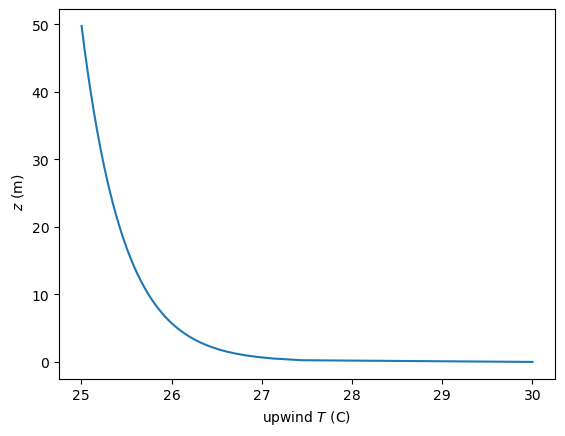

In [7]:
# Compute local Obukov length
Lo = - ustar**3/(k*g*FluxT[10, 0]/(273.15+Ts_d))
xi = z/Lo
print (Lo)

plt.plot(Tup, z)
plt.xlabel("upwind $T$ (C)")
plt.ylabel(" $z$ (m)")

Text(0.5, 1.0, 'Surface sensible and latent heat flux (W/m$^2$)')

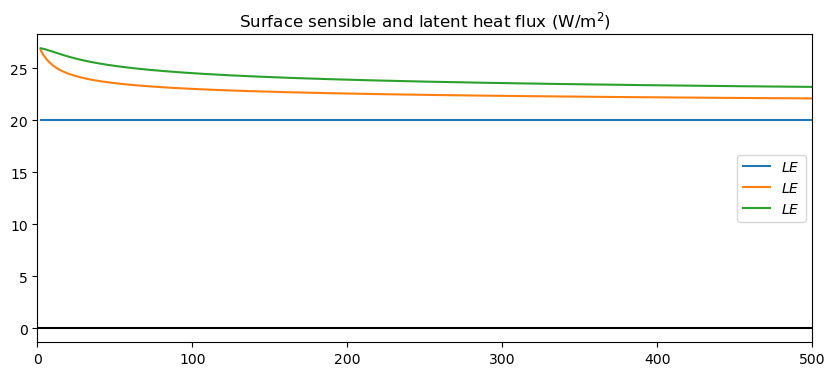

In [8]:
plt.figure(figsize = (10,4))
ax = plt.gca()
level = 0

ax.plot(x[1:], T[1:, level], label = "$LE$")
ax.plot(x[1:], T[1:, 1], label = "$LE$")
ax.plot(x[1:], T[1:, 3], label = "$LE$")

ax.legend()
ax.axhline(0, c= 'k')
ax.set_xlim(0, 500)
ax.set_title("Surface sensible and latent heat flux (W/m$^2$)")

Text(0.5, 1.0, 'Surface sensible and latent heat flux (W/m$^2$)')

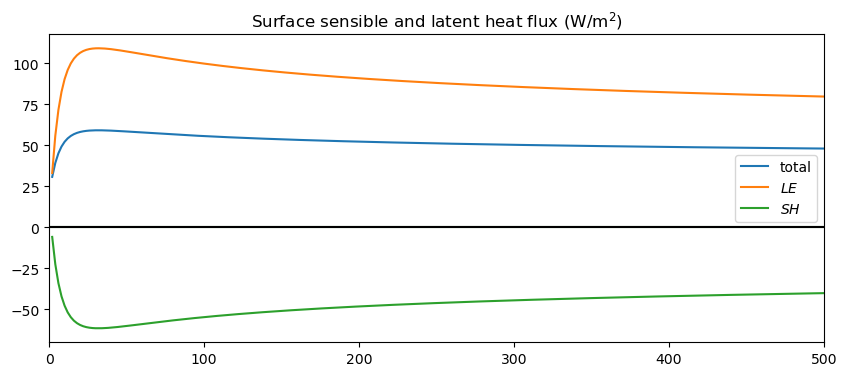

In [9]:
plt.figure(figsize = (10,4))
ax = plt.gca()
level = 0
FluxTotal = FluxT*1005*1.2 + FluxQ*2.5*1e6/1000
ax.plot(x[1:], FluxTotal[1:, level], label = 'total')
ax.plot(x[1:], FluxQ[1:, level]*2.260*1e6/1000, label = "$LE$")
ax.plot(x[1:], FluxT[1:, level]*1005*1.2, label = "$SH$")
ax.axhline(FluxT[-1, level], c = 'C2')
ax.legend()
ax.axhline(0, c= 'k')
ax.set_xlim(0, 500)
ax.set_title("Surface sensible and latent heat flux (W/m$^2$)")

    Upwind 
    SH = Rn
    LH = 0



In [10]:
xx, TT = padit(x, nz, Tup, T)
xx, QQ = padit(x, nz, Qup, Q)

xx, FluxQQ = padit(x, nz, FluxQ[0, :], FluxQ)
xx, FluxTT = padit(x, nz, FluxT[0, :], FluxT)


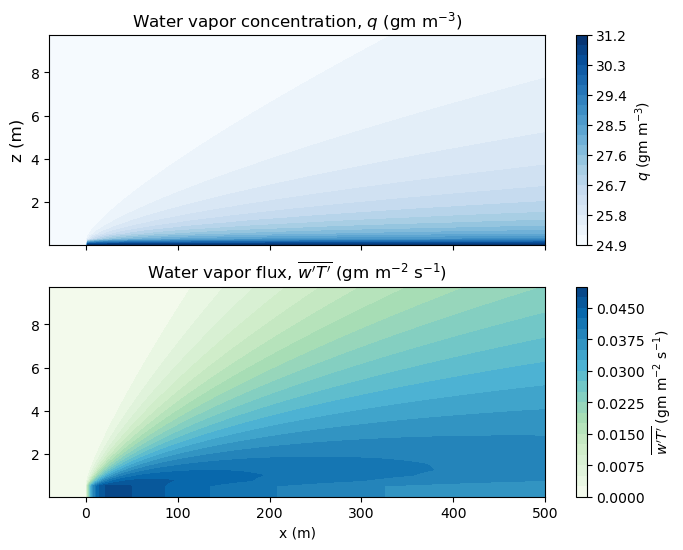

In [11]:
fig, axes = plt.subplots(2, 1, figsize = (8, 6), sharex = True)

xind = np.where(xx > 500)[0][0]
zind = np.where(z > 10)[0][0]
fontsize = 12

ax = axes[0]
g = axes[0].contourf(xx[:xind], z[:zind], QQ[:xind, :zind].T, 20, vmin = Ta_u, cmap = "Blues")
ax.set_ylabel("z (m)", fontsize = fontsize)
plt.colorbar(g, label="$q$ (gm m$^{-3}$)")
ax.set_title("Water vapor concentration, $q$ (gm m$^{-3}$)", fontsize=fontsize)

ax = axes[1]
g = axes[1].contourf(xx[:xind], z[:zind], FluxQQ[:xind, :zind].T, 20,  cmap = "GnBu")
ax.set_xlabel("x (m)")

ax.set_title("Water vapor flux, $\overline{w'T'}$ (gm m$^{-2}$ s$^{-1}$)", fontsize=fontsize)

plt.colorbar(g, label="$\overline{w'T'}$ (gm m$^{-2}$ s$^{-1}$)")

Text(0.5, 1.0, "$\\overline{w'q'} \\ $  ")

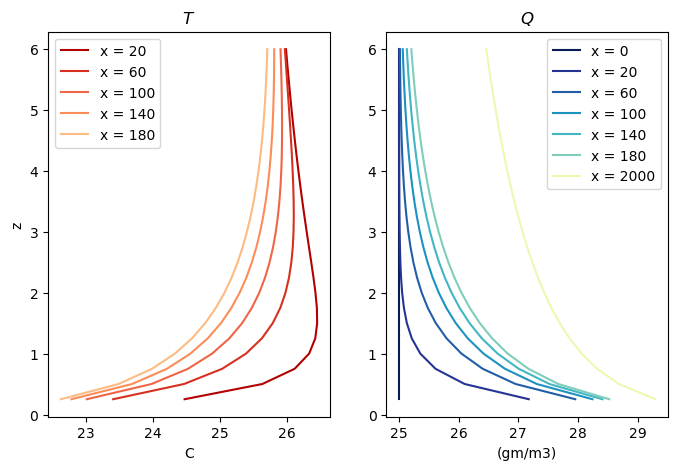

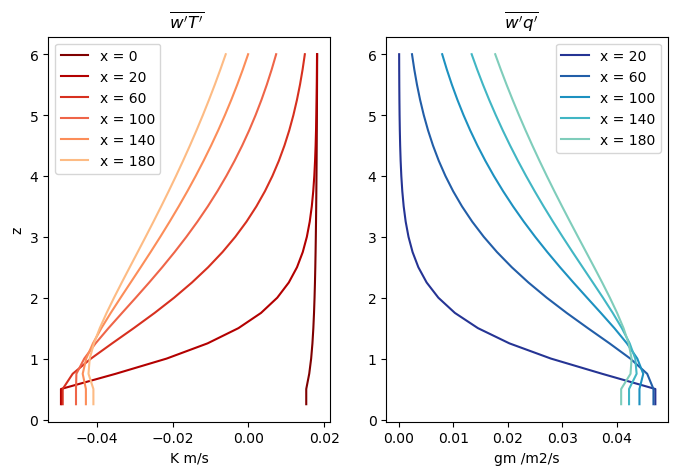

In [12]:
reds = ['#fff7ec','#fee8c8','#fdd49e','#fdbb84','#fc8d59','#ef6548','#d7301f','#b30000','#7f0000']
blues = ['#ffffd9','#edf8b1','#c7e9b4','#7fcdbb','#41b6c4','#1d91c0','#225ea8','#253494','#081d58']

zind = 25
xinds = np.arange(10, 100, 20)

fig, axes = plt.subplots(1,2, figsize = (8, 5))
ax = axes[0]
for ind, i in enumerate(xinds):
    ax.plot( T[i, 1:zind], z[1:zind], label = "x = {0:.0f}".format(x[i]), c = reds[-ind-2])
ax.legend()
ax.set_xlabel("C")
ax.set_ylabel("z")
ax.set_title("$T$")
ax = axes[1]

ax.plot( Q[0, 1:zind], z[1:zind], c = blues[-1], label = 'x = 0')
for ind, i in enumerate(xinds):
    ax.plot( Q[i, 1:zind], z[1:zind], label = "x = {0:.0f}".format(x[i]), c = blues[-ind-2])
ax.plot( Q[-1, 1:zind], z[1:zind], label = "x = {0:.0f}".format(x[-1]), c = blues[1])    
ax.legend()
ax.set_xlabel("(gm/m3)")
ax.set_title("$Q$ ")

fig, axes = plt.subplots(1,2, figsize = (8, 5))
ax = axes[0]
ax.plot( FluxT[0][1:zind], z[1:zind], c = reds[-1], label = 'x = 0')
for ind, i in enumerate(xinds):
    ax.plot( FluxT[i][1:zind], z[1:zind], label = "x = {0:.0f}".format(x[i]), c = reds[-ind-2])
ax.legend()

ax.set_xlabel("K m/s")
ax.set_ylabel("z")
ax.set_title("$\overline{w'T'} \ $ ")

ax = axes[1]
for ind, i in enumerate(xinds):
    ax.plot( FluxQ[i][1:zind], z[1:zind], label = "x = {0:.0f}".format(x[i]), c = blues[-ind-2])

ax.legend()
ax.set_xlabel("gm /m2/s")
ax.set_title("$\overline{w'q'} \ $  ")

Text(0.5, 1.0, "$\\overline{w'q'}$")

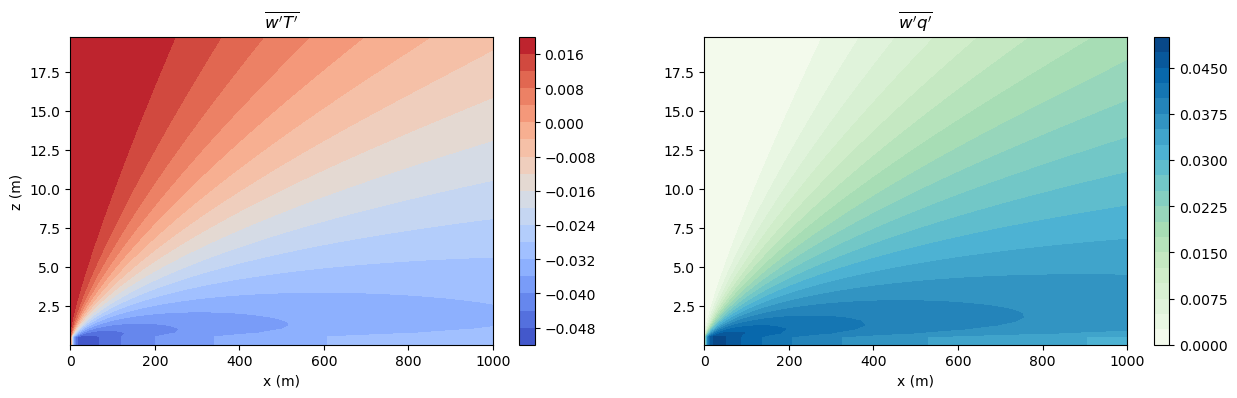

In [13]:
fig, axes = plt.subplots(1,2, figsize = (15, 4))

xind = np.where(x > 1000)[0][0]
zind = np.where(z > 20)[0][0]

ax = axes[0]
g = axes[0].contourf(x[:xind], z[:zind], FluxT[:xind, :zind].T, 20,cmap = "coolwarm")
ax.set_xlabel("x (m)")
ax.set_ylabel("z (m)")
plt.colorbar(g)

ax.set_title("$\overline{w'T'}$")

ax = axes[1]
g = axes[1].contourf(x[:xind], z[:zind], FluxQ[:xind, :zind].T, 20,  cmap = "GnBu")
ax.set_xlabel("x (m)")
plt.colorbar(g)
ax.set_title("$\overline{w'q'}$")


Text(0.5, 1.0, 'z < 20 m')

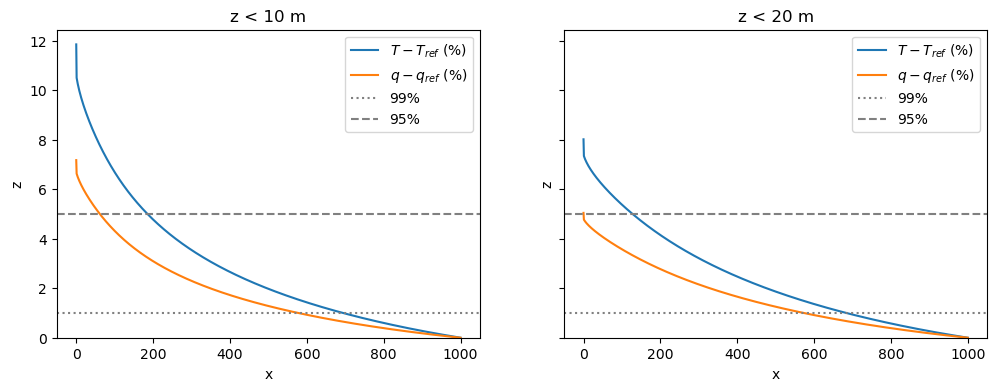

In [14]:
fig, axes = plt.subplots(1,2, sharey = True, figsize = (12, 4))
ax = axes[0]

ind = np.where(z> 10)[0][0]
ref = T[-1][:ind]
ax.plot(( ((T[:, :ind] - ref)/ref).T).mean(0)*100, label = "$T - T_{ref}$ (%)")
ref = Q[-1][:ind]
ax.plot(  ( ( (- Q[:, :ind] + ref)/ref).T).mean(0)*100, label = "$q - q_{ref}$ (%)")
ax.axhline(1, ls = ":", c = 'grey', label = "99%")
ax.axhline(5, ls = "--", c = 'grey', label = "95%")
ax.set_ylim(0) 
ax.legend()
ax.set_ylabel("z")
ax.set_xlabel("x")
ax.set_title("z < 10 m" )

ax = axes[1]
ind = np.where(z> 20)[0][0]
ref = T[-1][:ind]
ax.plot(( ((T[:, :ind] - ref)/ref).T).mean(0)*100, label = "$T - T_{ref}$ (%)")
ref = Q[-1][:ind]
ax.plot(  ( ( (- Q[:, :ind] + ref)/ref).T).mean(0)*100, label = "$q - q_{ref}$ (%)")
ax.axhline(1, ls = ":", c = 'grey', label = "99%")
ax.axhline(5, ls = "--", c = 'grey', label = "95%")
ax.set_ylim(0)
ax.legend()
ax.set_ylabel("z")
ax.set_xlabel("x")
ax.set_title("z < 20 m" )

Text(0.5, 1.0, 'z < 20 m')

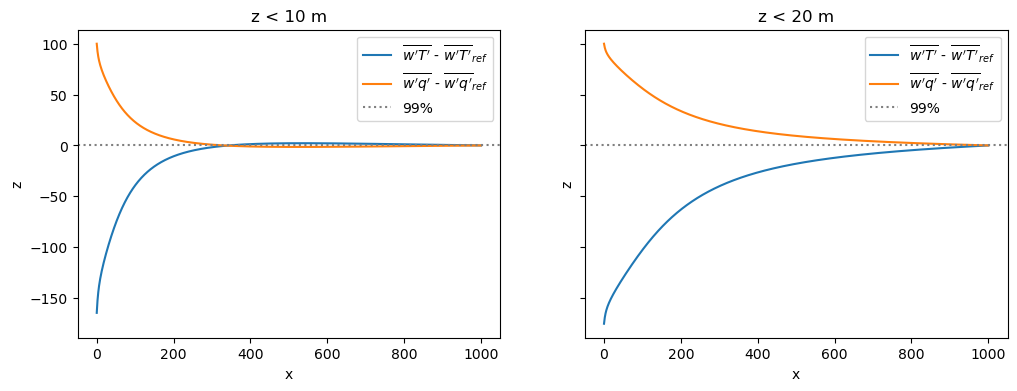

In [15]:
fig, axes = plt.subplots(1,2, sharey = True, figsize = (12, 4))
ax = axes[0]

ind = np.where(z> 10)[0][0]
ref = FluxT[-1][:ind]
ax.plot(( ((FluxT[:, :ind] - ref)/ref).T).mean(0)*100, label = "$\overline{w'T'}$ - $\overline{w'T'}_{ref}$ ")
ref = FluxQ[-1][:ind]
ax.plot(  ( ( (- FluxQ[:, :ind] + ref)/ref).T).mean(0)*100, label = "$\overline{w'q'}$ - $\overline{w'q'}_{ref}$ ")
ax.axhline(0, ls = ":", c = 'grey', label = "99%")
# ax.set_ylim(0) 
ax.legend()
ax.set_ylabel("z")
ax.set_xlabel("x")
ax.set_title("z < 10 m" )

ax = axes[1]
ind = np.where(z> 20)[0][0]
ref = FluxT[-1][:ind]
ax.plot(( ((FluxT[:, :ind] - ref)/ref).T).mean(0)*100, label = "$\overline{w'T'}$ - $\overline{w'T'}_{ref}$ ")
ref = FluxQ[-1][:ind]
ax.plot(  ( ( (- FluxQ[:, :ind] + ref)/ref).T).mean(0)*100, label = "$\overline{w'q'}$ - $\overline{w'q'}_{ref}$ ")
ax.axhline(0, ls = ":", c = 'grey', label = "99%")
# ax.set_ylim(0)
ax.legend()
ax.set_ylabel("z")
ax.set_xlabel("x")
ax.set_title("z < 20 m" )


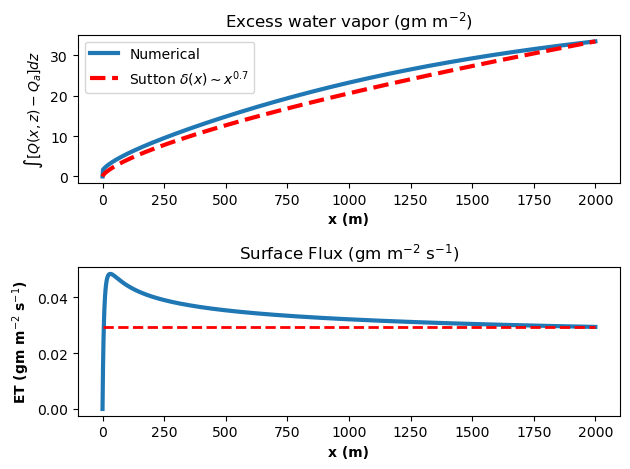

In [16]:

# Plot excess water vapor and surface flux
plt.figure(2)
plt.clf()
QQ = np.sum(Q - Qa, axis=1) * dz

plt.subplot(2, 1, 1)
plt.plot(x, QQ, '-', linewidth=3)
plt.plot(x, np.max(QQ) * (x / Lx) ** 0.7, 'r--', linewidth=3)
plt.xlabel('x (m)', fontsize=10, fontweight='bold')
plt.ylabel(r'$\int [Q(x,z) - Q_a]dz$', fontsize=10, fontweight='bold')
plt.title('Excess water vapor (gm m$^{-2}$)', fontsize=12)
plt.legend(['Numerical', 'Sutton $\delta(x) \sim x^{0.7}$'], loc='upper left')

plt.subplot(2, 1, 2)
plt.plot(x, FluxQ[:, 0], '-', linewidth=3)
plt.plot(x, np.ones(nx + 1) * FluxQ[nx, 0], 'r--', linewidth=2)
plt.xlabel('x (m)', fontsize=10, fontweight='bold')
plt.ylabel('ET (gm m$^{-2}$ s$^{-1}$)', fontsize=10, fontweight='bold')
plt.title('Surface Flux (gm m$^{-2}$ s$^{-1}$)', fontsize=12)

plt.tight_layout()
plt.show()


Text(0.5, 1.0, '$(Q-Q_a)/(Q_s-Q_a)$')

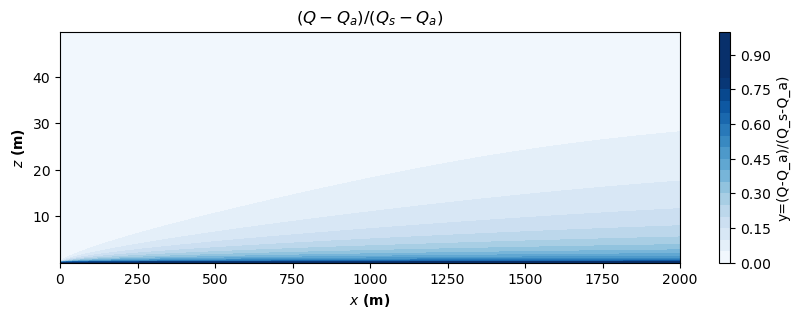

In [17]:

# Normalized concentration
Qd = (Q - Qa) / (Qs - Qa)

plt.figure(3, figsize = (10,3))
plt.clf()
plt.contourf(x, z, Qd.T.round(5), 20, vmax = 0.8, cmap='Blues')
plt.xlabel(r'$\it{x}$ (m)', fontweight='bold', fontsize=10)
plt.ylabel(r'$\it{z}$ (m)', fontweight='bold', fontsize=10)
plt.colorbar(label='y=(Q-Q_a)/(Q_s-Q_a)')
plt.title('$(Q-Q_a)/(Q_s-Q_a)$')
